1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

2. Load Cleaned Dataset from Notebook 1

In [2]:
file_path = "StudentPerformanceFactors_cleaned.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.head()

Dataset Shape: (6607, 20)

Columns:
 ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


3. Define Focus Variables

In [3]:
focus_cols = [
    "Motivation_Level",
    "Peer_Influence",
    "Access_to_Resources",
    "Exam_Score"
]

print("Focus Columns:", focus_cols)
display(df[focus_cols].head())

Focus Columns: ['Motivation_Level', 'Peer_Influence', 'Access_to_Resources', 'Exam_Score']


,Motivation_Level,Peer_Influence,Access_to_Resources,Exam_Score
0,Low,Positive,High,67
1,Low,Negative,Medium,61
2,Medium,Neutral,Medium,74
3,Medium,Negative,Medium,71
4,Medium,Neutral,Medium,70


4. Inspect Missing Values and Categories in Focus Variables

In [4]:
print("Missing Values:\n")
display(df[focus_cols].isnull().sum())

for col in ["Motivation_Level", "Peer_Influence", "Access_to_Resources"]:
    print(f"\nValue Counts for {col}:")
    display(df[col].value_counts())

Missing Values:



Motivation_Level       0
Peer_Influence         0
Access_to_Resources    0
Exam_Score             0
dtype: int64


Value Counts for Motivation_Level:


Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64


Value Counts for Peer_Influence:


Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64


Value Counts for Access_to_Resources:


Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

5. Create Working Copy for Feature Engineering

In [5]:
df_fe = df.copy()
print("Working copy created.")

Working copy created.


6. Encode the Three Psychosocial Variables

In [6]:
# Ordinal mappings preserve the natural order of the categories

motivation_map = {"Low": 1, "Medium": 2, "High": 3}
peer_map = {"Negative": 1, "Neutral": 2, "Positive": 3}
resource_map = {"Low": 1, "Medium": 2, "High": 3}

df_fe["Motivation_Level_Encoded"] = df_fe["Motivation_Level"].map(motivation_map)
df_fe["Peer_Influence_Encoded"] = df_fe["Peer_Influence"].map(peer_map)
df_fe["Access_to_Resources_Encoded"] = df_fe["Access_to_Resources"].map(resource_map)

display(df_fe[[
    "Motivation_Level", "Motivation_Level_Encoded",
    "Peer_Influence", "Peer_Influence_Encoded",
    "Access_to_Resources", "Access_to_Resources_Encoded"
]].head(10))

,Motivation_Level,Motivation_Level_Encoded,Peer_Influence,Peer_Influence_Encoded,Access_to_Resources,Access_to_Resources_Encoded
0,Low,1,Positive,3,High,3
1,Low,1,Negative,1,Medium,2
2,Medium,2,Neutral,2,Medium,2
3,Medium,2,Negative,1,Medium,2
4,Medium,2,Neutral,2,Medium,2
5,Medium,2,Positive,3,Medium,2
6,Low,1,Neutral,2,Low,1
7,Medium,2,Negative,1,High,3
8,High,3,Neutral,2,High,3
9,Medium,2,Positive,3,Medium,2


7. Verify Encoding Integrity

In [7]:
print("Check for NaN values after encoding:\n")
display(df_fe[[
    "Motivation_Level_Encoded",
    "Peer_Influence_Encoded",
    "Access_to_Resources_Encoded"
]].isnull().sum())

print("\nUnique Encoded Values:")
print("Motivation:", sorted(df_fe["Motivation_Level_Encoded"].dropna().unique()))
print("Peer:", sorted(df_fe["Peer_Influence_Encoded"].dropna().unique()))
print("Resources:", sorted(df_fe["Access_to_Resources_Encoded"].dropna().unique()))

Check for NaN values after encoding:



Motivation_Level_Encoded       0
Peer_Influence_Encoded         0
Access_to_Resources_Encoded    0
dtype: int64


Unique Encoded Values:
Motivation: [np.int64(1), np.int64(2), np.int64(3)]
Peer: [np.int64(1), np.int64(2), np.int64(3)]
Resources: [np.int64(1), np.int64(2), np.int64(3)]


8. Normalize Encoded Variables to 0-1 Scale

In [8]:
# 1 -> 0.0, 2 -> 0.5, 3 -> 1.0

df_fe["Motivation_Normalized"] = (df_fe["Motivation_Level_Encoded"] - 1) / 2
df_fe["Peer_Normalized"] = (df_fe["Peer_Influence_Encoded"] - 1) / 2
df_fe["Resources_Normalized"] = (df_fe["Access_to_Resources_Encoded"] - 1) / 2

display(df_fe[[
    "Motivation_Level_Encoded", "Motivation_Normalized",
    "Peer_Influence_Encoded", "Peer_Normalized",
    "Access_to_Resources_Encoded", "Resources_Normalized"
]].head(10))

,Motivation_Level_Encoded,Motivation_Normalized,Peer_Influence_Encoded,Peer_Normalized,Access_to_Resources_Encoded,Resources_Normalized
0,1,0.0,3,1.0,3,1.0
1,1,0.0,1,0.0,2,0.5
2,2,0.5,2,0.5,2,0.5
3,2,0.5,1,0.0,2,0.5
4,2,0.5,2,0.5,2,0.5
5,2,0.5,3,1.0,2,0.5
6,1,0.0,2,0.5,1,0.0
7,2,0.5,1,0.0,3,1.0
8,3,1.0,2,0.5,3,1.0
9,2,0.5,3,1.0,2,0.5


9. Create Core Composite Feature

In [9]:
# Motivation = 0.25
# Peer = 0.30
# Resources = 0.45

df_fe["Psychosocial_Resource_Score"] = (
    df_fe["Motivation_Normalized"] * 0.25 +
    df_fe["Peer_Normalized"] * 0.30 +
    df_fe["Resources_Normalized"] * 0.45
)

display(df_fe[[
    "Motivation_Normalized",
    "Peer_Normalized",
    "Resources_Normalized",
    "Psychosocial_Resource_Score"
]].head(10))

,Motivation_Normalized,Peer_Normalized,Resources_Normalized,Psychosocial_Resource_Score
0,0.0,1.0,1.0,0.750
1,0.0,0.0,0.5,0.225
2,0.5,0.5,0.5,0.500
3,0.5,0.0,0.5,0.350
4,0.5,0.5,0.5,0.500
5,0.5,1.0,0.5,0.650
6,0.0,0.5,0.0,0.150
7,0.5,0.0,1.0,0.575
8,1.0,0.5,1.0,0.850
9,0.5,1.0,0.5,0.650


10. Create Interaction Features

In [10]:
df_fe["Motivation_x_Peer"] = (
    df_fe["Motivation_Normalized"] * df_fe["Peer_Normalized"]
)

df_fe["Motivation_x_Resources"] = (
    df_fe["Motivation_Normalized"] * df_fe["Resources_Normalized"]
)

df_fe["Peer_x_Resources"] = (
    df_fe["Peer_Normalized"] * df_fe["Resources_Normalized"]
)

df_fe["Triadic_Support_Index"] = (
    df_fe["Motivation_Normalized"] *
    df_fe["Peer_Normalized"] *
    df_fe["Resources_Normalized"]
)

print("Interaction features created.")

Interaction features created.


11. Inspect Engineered Feature Summary Statistics

In [11]:
engineered_cols = [
    "Motivation_Level_Encoded",
    "Peer_Influence_Encoded",
    "Access_to_Resources_Encoded",
    "Motivation_Normalized",
    "Peer_Normalized",
    "Resources_Normalized",
    "Psychosocial_Resource_Score",
    "Motivation_x_Peer",
    "Motivation_x_Resources",
    "Peer_x_Resources",
    "Triadic_Support_Index"
]

display(df_fe[engineered_cols].describe())

,Motivation_Level_Encoded,Peer_Influence_Encoded,Access_to_Resources_Encoded,Motivation_Normalized,Peer_Normalized,Resources_Normalized,Psychosocial_Resource_Score,Motivation_x_Peer,Motivation_x_Resources,Peer_x_Resources,Triadic_Support_Index
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.00000,6607.000000
mean,1.906463,2.190858,2.100197,0.453231,0.595429,0.550098,0.539481,0.269827,0.250076,0.32738,0.149292
std,0.695798,0.755876,0.698347,0.347899,0.377938,0.349173,0.212670,0.299397,0.274772,0.32228,0.217054
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,1.000000,2.000000,2.000000,0.000000,0.500000,0.500000,0.375000,0.000000,0.000000,0.00000,0.000000
50%,2.000000,2.000000,2.000000,0.500000,0.500000,0.500000,0.525000,0.250000,0.250000,0.25000,0.000000
75%,2.000000,3.000000,3.000000,0.500000,1.000000,1.000000,0.700000,0.500000,0.500000,0.50000,0.250000
max,3.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


12. Compare Mean Exam Score by Each Raw Psychosocial Variable

In [12]:
print("Mean Exam Score by Motivation_Level:")
display(df_fe.groupby("Motivation_Level")["Exam_Score"].mean())

print("\nMean Exam Score by Peer_Influence:")
display(df_fe.groupby("Peer_Influence")["Exam_Score"].mean())

print("\nMean Exam Score by Access_to_Resources:")
display(df_fe.groupby("Access_to_Resources")["Exam_Score"].mean())

Mean Exam Score by Motivation_Level:


Motivation_Level
High      67.704321
Low       66.752194
Medium    67.330648
Name: Exam_Score, dtype: float64


Mean Exam Score by Peer_Influence:


Peer_Influence
Negative    66.564270
Neutral     67.197917
Positive    67.623199
Name: Exam_Score, dtype: float64


Mean Exam Score by Access_to_Resources:


Access_to_Resources
High      68.092152
Low       66.203351
Medium    67.134378
Name: Exam_Score, dtype: float64

13. Visualize Exam Score by Each Raw Psychosocial Variable

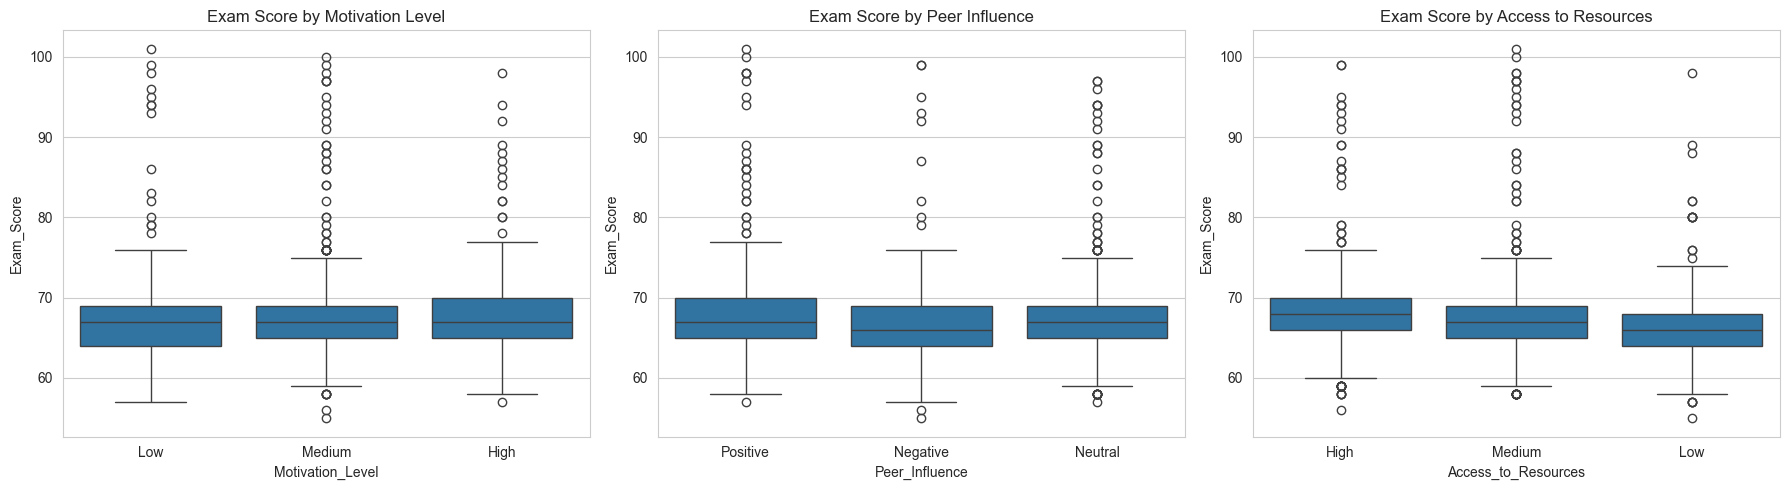

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_fe, x="Motivation_Level", y="Exam_Score", ax=axes[0])
axes[0].set_title("Exam Score by Motivation Level")

sns.boxplot(data=df_fe, x="Peer_Influence", y="Exam_Score", ax=axes[1])
axes[1].set_title("Exam Score by Peer Influence")

sns.boxplot(data=df_fe, x="Access_to_Resources", y="Exam_Score", ax=axes[2])
axes[2].set_title("Exam Score by Access to Resources")

plt.tight_layout()
plt.show()

14. Correlation of Engineered Features with Exam_Score

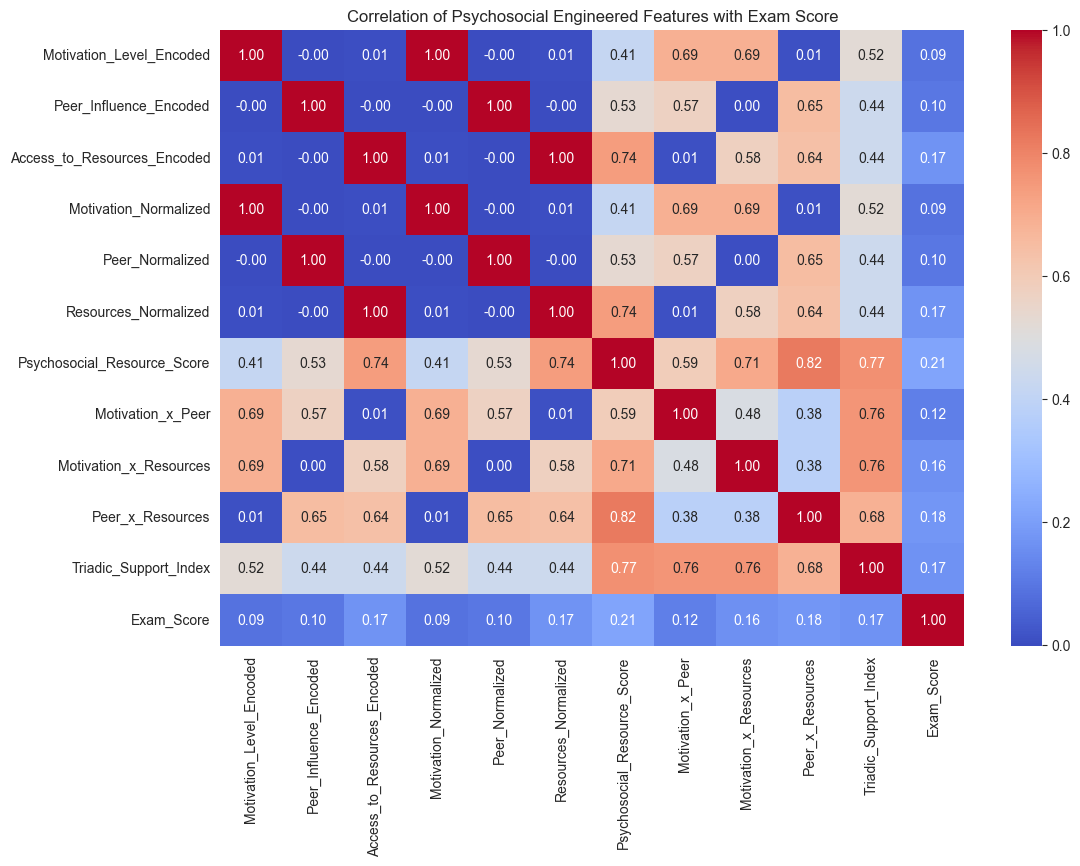


Correlation with Exam_Score:


Exam_Score                     1.000000
Psychosocial_Resource_Score    0.214416
Peer_x_Resources               0.175790
Access_to_Resources_Encoded    0.169770
Resources_Normalized           0.169770
Triadic_Support_Index          0.166344
Motivation_x_Resources         0.159788
Motivation_x_Peer              0.118866
Peer_Influence_Encoded         0.100217
Peer_Normalized                0.100217
Motivation_Normalized          0.086937
Motivation_Level_Encoded       0.086937
Name: Exam_Score, dtype: float64

In [14]:
corr_cols = engineered_cols + ["Exam_Score"]
corr_matrix = df_fe[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Psychosocial Engineered Features with Exam Score")
plt.show()

print("\nCorrelation with Exam_Score:")
display(corr_matrix["Exam_Score"].sort_values(ascending=False))

15. Create Quartiles of Composite Score

In [15]:
df_fe["Psychosocial_Resource_Quartile"] = pd.qcut(
    df_fe["Psychosocial_Resource_Score"],
    4,
    labels=["Q1_Low", "Q2", "Q3", "Q4_High"]
)

display(df_fe[[
    "Psychosocial_Resource_Score",
    "Psychosocial_Resource_Quartile"
]].head(10))

,Psychosocial_Resource_Score,Psychosocial_Resource_Quartile
0,0.750,Q4_High
1,0.225,Q1_Low
2,0.500,Q2
3,0.350,Q1_Low
4,0.500,Q2
5,0.650,Q3
6,0.150,Q1_Low
7,0.575,Q3
8,0.850,Q4_High
9,0.650,Q3


16. Compare Mean Exam Score Across Composite Score Quartiles

Psychosocial_Resource_Quartile
Q1_Low     66.170565
Q2         66.975524
Q3         67.614035
Q4_High    68.318324
Name: Exam_Score, dtype: float64

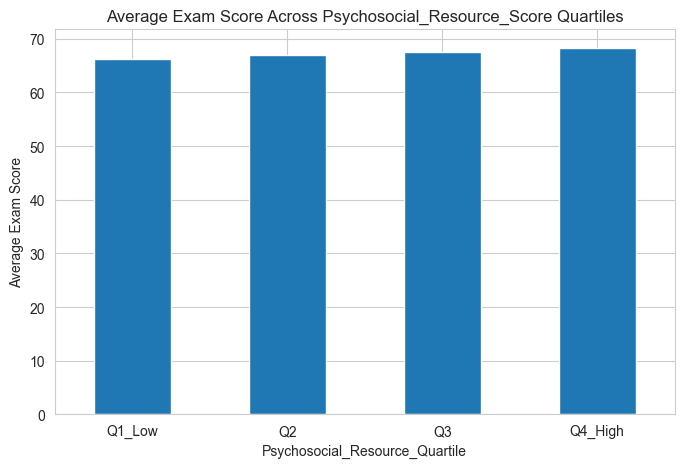

In [16]:
quartile_means = df_fe.groupby("Psychosocial_Resource_Quartile")["Exam_Score"].mean()
display(quartile_means)

plt.figure(figsize=(8, 5))
quartile_means.plot(kind="bar")
plt.title("Average Exam Score Across Psychosocial_Resource_Score Quartiles")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=0)
plt.show()

17. Optional: Create a Simple Focused Risk Flag

In [17]:
# At_Risk if all three normalized variables are below 0.5

df_fe["Focused_Risk_Flag"] = np.where(
    (df_fe["Motivation_Normalized"] < 0.5) &
    (df_fe["Peer_Normalized"] < 0.5) &
    (df_fe["Resources_Normalized"] < 0.5),
    "At_Risk",
    "Not_At_Risk"
)

print("Risk Flag Counts:")
display(df_fe["Focused_Risk_Flag"].value_counts())

print("\nMean Exam Score by Risk Flag:")
display(df_fe.groupby("Focused_Risk_Flag")["Exam_Score"].mean())

Risk Flag Counts:


Focused_Risk_Flag
Not_At_Risk    6520
At_Risk          87
Name: count, dtype: int64


Mean Exam Score by Risk Flag:


Focused_Risk_Flag
At_Risk        65.367816
Not_At_Risk    67.260583
Name: Exam_Score, dtype: float64

18. Final Verification Table

In [18]:
verification_cols = [
    "Motivation_Level",
    "Peer_Influence",
    "Access_to_Resources",
    "Exam_Score",
    "Motivation_Level_Encoded",
    "Peer_Influence_Encoded",
    "Access_to_Resources_Encoded",
    "Motivation_Normalized",
    "Peer_Normalized",
    "Resources_Normalized",
    "Psychosocial_Resource_Score",
    "Motivation_x_Peer",
    "Motivation_x_Resources",
    "Peer_x_Resources",
    "Triadic_Support_Index",
    "Psychosocial_Resource_Quartile",
    "Focused_Risk_Flag"
]

display(df_fe[verification_cols].head(15))

,Motivation_Level,Peer_Influence,Access_to_Resources,Exam_Score,Motivation_Level_Encoded,Peer_Influence_Encoded,Access_to_Resources_Encoded,Motivation_Normalized,Peer_Normalized,Resources_Normalized,Psychosocial_Resource_Score,Motivation_x_Peer,Motivation_x_Resources,Peer_x_Resources,Triadic_Support_Index,Psychosocial_Resource_Quartile,Focused_Risk_Flag
0,Low,Positive,High,67,1,3,3,0.0,1.0,1.0,0.750,0.00,0.00,1.00,0.000,Q4_High,Not_At_Risk
1,Low,Negative,Medium,61,1,1,2,0.0,0.0,0.5,0.225,0.00,0.00,0.00,0.000,Q1_Low,Not_At_Risk
2,Medium,Neutral,Medium,74,2,2,2,0.5,0.5,0.5,0.500,0.25,0.25,0.25,0.125,Q2,Not_At_Risk
3,Medium,Negative,Medium,71,2,1,2,0.5,0.0,0.5,0.350,0.00,0.25,0.00,0.000,Q1_Low,Not_At_Risk
4,Medium,Neutral,Medium,70,2,2,2,0.5,0.5,0.5,0.500,0.25,0.25,0.25,0.125,Q2,Not_At_Risk
5,Medium,Positive,Medium,71,2,3,2,0.5,1.0,0.5,0.650,0.50,0.25,0.50,0.250,Q3,Not_At_Risk
6,Low,Neutral,Low,67,1,2,1,0.0,0.5,0.0,0.150,0.00,0.00,0.00,0.000,Q1_Low,Not_At_Risk
7,Medium,Negative,High,66,2,1,3,0.5,0.0,1.0,0.575,0.00,0.50,0.00,0.000,Q3,Not_At_Risk
8,High,Neutral,High,69,3,2,3,1.0,0.5,1.0,0.850,0.50,1.00,0.50,0.500,Q4_High,Not_At_Risk
9,Medium,Positive,Medium,72,2,3,2,0.5,1.0,0.5,0.650,0.50,0.25,0.50,0.250,Q3,Not_At_Risk


19. Save Feature-Engineered Dataset

In [19]:
output_file = "StudentPerformanceFactors_psychology_engineered.csv"
df_fe.to_csv(output_file, index=False)

print(f"Feature-engineered dataset saved as: {output_file}")

Feature-engineered dataset saved as: StudentPerformanceFactors_psychology_engineered.csv


20. Final Notebook Summary

In [20]:
print("=== NOTEBOOK 2 COMPLETE ===")
print("Saved file: StudentPerformanceFactors_psychology_engineered.csv")
print("\nThis notebook created:")
print("- Encoded psychosocial variables")
print("- Normalized psychosocial variables")
print("- Weighted Psychosocial_Resource_Score")
print("- Pairwise interaction features")
print("- Triadic support feature")
print("- Composite quartile grouping")
print("- Optional focused risk flag")

=== NOTEBOOK 2 COMPLETE ===
Saved file: StudentPerformanceFactors_psychology_engineered.csv

This notebook created:
- Encoded psychosocial variables
- Normalized psychosocial variables
- Weighted Psychosocial_Resource_Score
- Pairwise interaction features
- Triadic support feature
- Composite quartile grouping
- Optional focused risk flag
